<a href="https://colab.research.google.com/github/heavyrainseo/deeplearning/blob/main/regression_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 연습용 노트

In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 52.3 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3
import duckdb

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

## geyser 데이터

In [4]:
gs = sns.load_dataset('geyser')
print(gs.head())
print(gs.info())

   duration  waiting   kind
0     3.600       79   long
1     1.800       54  short
2     3.333       74   long
3     2.283       62  short
4     4.533       85   long
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duration  272 non-null    float64
 1   waiting   272 non-null    int64  
 2   kind      272 non-null    object 
dtypes: float64(1), int64(1), object(1)
memory usage: 6.5+ KB
None


In [9]:
print(gs.mean(numeric_only=True))
print(gs.groupby('kind').count())

duration     3.487783
waiting     70.897059
dtype: float64
       duration  waiting
kind                    
long        172      172
short       100      100


<Axes: ylabel='Count'>

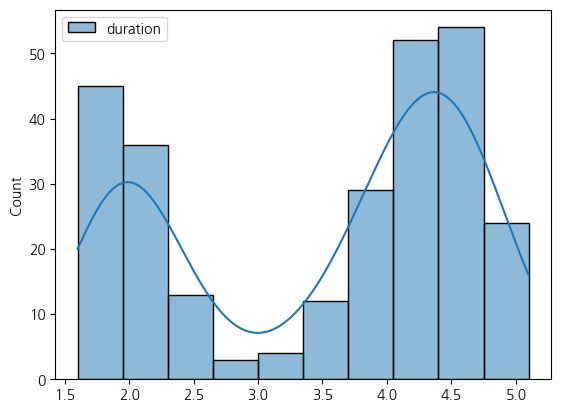

In [96]:
sns.histplot(gs[['duration']], kde=True)

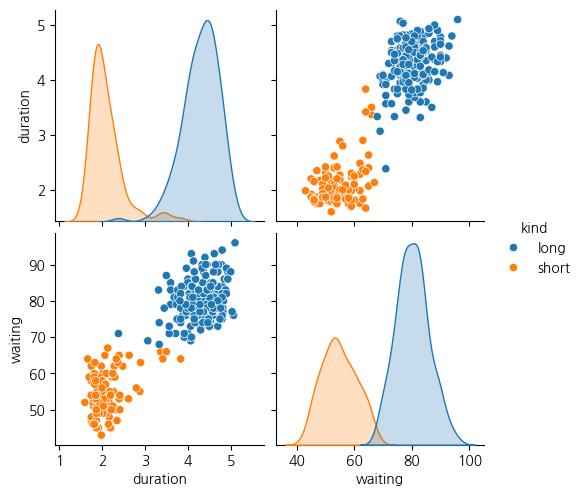

In [ ]:
sns.pairplot(gs, hue='kind')

<Axes: >

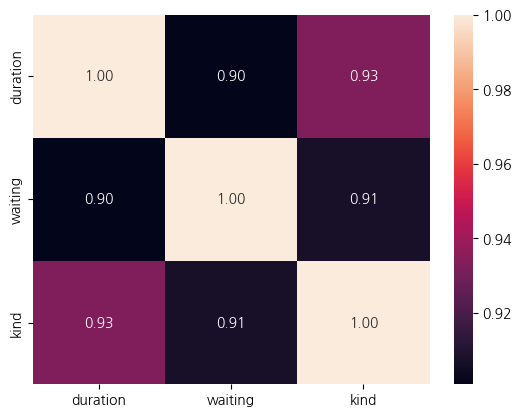

In [28]:
sns.heatmap(gs_kind.corr(), annot=True, fmt='.2f')

### Linear Regression

In [84]:
# 정규화하지 않으면 발산
x = ((gs.waiting-gs.waiting.min())/(gs.waiting.max()-gs.waiting.min())).copy()
y = gs.duration.copy()
x, y

(0      0.679245
 1      0.207547
 2      0.584906
 3      0.358491
 4      0.792453
          ...   
 267    0.716981
 268    0.056604
 269    0.886792
 270    0.056604
 271    0.584906
 Name: waiting, Length: 272, dtype: float64,
 0      3.600
 1      1.800
 2      3.333
 3      2.283
 4      4.533
        ...  
 267    4.117
 268    2.150
 269    4.417
 270    1.817
 271    4.467
 Name: duration, Length: 272, dtype: float64)

In [85]:
#@title LR Model
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='sgd', loss='mse')
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [86]:
esc = EarlyStopping(patience=10, monitor='loss')

hist = model.fit(x, y, callbacks=[esc], validation_split=0.2, epochs=10000, batch_size=16, verbose=2)

Epoch 1/10000
14/14 - 0s - 25ms/step - loss: 8.3402 - val_loss: 5.7690
Epoch 2/10000
14/14 - 0s - 8ms/step - loss: 4.3060 - val_loss: 3.0293
Epoch 3/10000
14/14 - 0s - 8ms/step - loss: 2.3372 - val_loss: 1.6894
Epoch 4/10000
14/14 - 0s - 7ms/step - loss: 1.3898 - val_loss: 1.0543
Epoch 5/10000
14/14 - 0s - 7ms/step - loss: 0.9377 - val_loss: 0.7247
Epoch 6/10000
14/14 - 0s - 7ms/step - loss: 0.7112 - val_loss: 0.5624
Epoch 7/10000
14/14 - 0s - 7ms/step - loss: 0.5992 - val_loss: 0.4763
Epoch 8/10000
14/14 - 0s - 8ms/step - loss: 0.5429 - val_loss: 0.4296
Epoch 9/10000
14/14 - 0s - 8ms/step - loss: 0.5097 - val_loss: 0.3998
Epoch 10/10000
14/14 - 0s - 7ms/step - loss: 0.4900 - val_loss: 0.3826
Epoch 11/10000
14/14 - 0s - 9ms/step - loss: 0.4777 - val_loss: 0.3714
Epoch 12/10000
14/14 - 0s - 8ms/step - loss: 0.4691 - val_loss: 0.3623
Epoch 13/10000
14/14 - 0s - 7ms/step - loss: 0.4617 - val_loss: 0.3551
Epoch 14/10000
14/14 - 0s - 7ms/step - loss: 0.4550 - val_loss: 0.3498
Epoch 15/10000

In [87]:
model.get_weights()

[array([[4.0127554]], dtype=float32), array([1.3736342], dtype=float32)]

In [88]:
model.evaluate(x,y)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2447 


0.24471771717071533

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


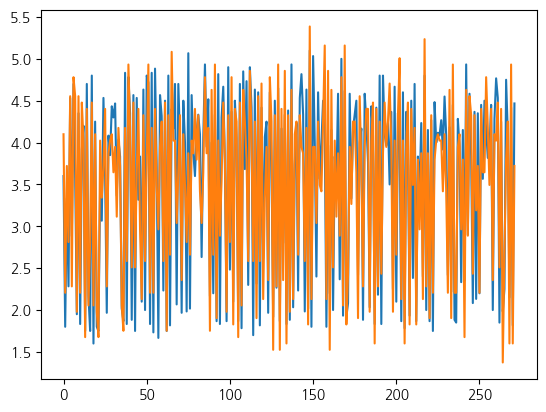

In [89]:
pred = np.array(model.predict(x).flatten())
plt.plot(gs.duration)
plt.plot(pred)

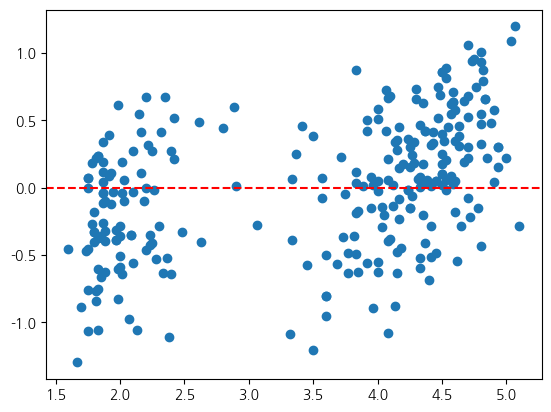

In [105]:
residual = gs.duration - pred
plt.scatter(gs.duration, residual)
plt.axhline(0, color='red', linestyle='--')

### Logistic Regression

In [97]:
gs_kind = gs.copy()
gs_kind['kind'] = gs_kind.kind.map({'long':1, 'short':0}).copy()
gs_kind

,duration,waiting,kind
0,3.600,79,1
1,1.800,54,0
2,3.333,74,1
3,2.283,62,0
4,4.533,85,1
...,...,...,...
267,4.117,81,1
268,2.150,46,0
269,4.417,90,1
270,1.817,46,0


In [98]:
x = gs_kind[['duration', 'waiting']].copy()
y = gs_kind.kind
x, y

(     duration  waiting
 0       3.600       79
 1       1.800       54
 2       3.333       74
 3       2.283       62
 4       4.533       85
 ..        ...      ...
 267     4.117       81
 268     2.150       46
 269     4.417       90
 270     1.817       46
 271     4.467       74
 
 [272 rows x 2 columns],
 0      1
 1      0
 2      1
 3      0
 4      1
       ..
 267    1
 268    0
 269    1
 270    0
 271    1
 Name: kind, Length: 272, dtype: int64)

In [99]:
#@title create model
model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [100]:
esc = EarlyStopping(patience=10, monitor='loss')
hist = model.fit(x, y, callbacks=[esc], validation_split=0.2, epochs=100000, batch_size=16, verbose=2)

Epoch 1/100000
14/14 - 1s - 72ms/step - accuracy: 0.6267 - loss: 10.1190 - val_accuracy: 0.6545 - val_loss: 8.7780
Epoch 2/100000
14/14 - 0s - 7ms/step - accuracy: 0.6267 - loss: 9.1114 - val_accuracy: 0.6545 - val_loss: 7.8553
Epoch 3/100000
14/14 - 0s - 8ms/step - accuracy: 0.6267 - loss: 8.1176 - val_accuracy: 0.6545 - val_loss: 6.8959
Epoch 4/100000
14/14 - 0s - 8ms/step - accuracy: 0.6267 - loss: 7.0783 - val_accuracy: 0.6545 - val_loss: 5.9661
Epoch 5/100000
14/14 - 0s - 8ms/step - accuracy: 0.6267 - loss: 6.0646 - val_accuracy: 0.6545 - val_loss: 5.0049
Epoch 6/100000
14/14 - 0s - 9ms/step - accuracy: 0.6267 - loss: 4.9750 - val_accuracy: 0.6545 - val_loss: 4.0612
Epoch 7/100000
14/14 - 0s - 8ms/step - accuracy: 0.6267 - loss: 3.9308 - val_accuracy: 0.6545 - val_loss: 3.0445
Epoch 8/100000
14/14 - 0s - 8ms/step - accuracy: 0.6267 - loss: 2.8243 - val_accuracy: 0.6545 - val_loss: 2.0479
Epoch 9/100000
14/14 - 0s - 8ms/step - accuracy: 0.6267 - loss: 1.7249 - val_accuracy: 0.6545 

In [101]:
model.evaluate(x, y)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9779 - loss: 0.0814 


[0.08142298460006714, 0.9779411554336548]

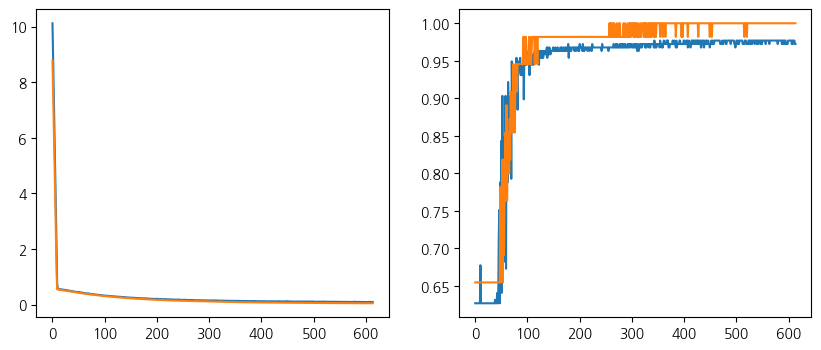

In [102]:
plt.figure(figsize=(10,4))

res = pd.DataFrame(hist.history)

ax = plt.subplot(1,2,1)
plt.plot(res[['loss','val_loss']])

ax = plt.subplot(1,2,2)
plt.plot(res[['accuracy','val_accuracy']])

plt.show()


In [103]:
result = pd.DataFrame({'real':y, 'predict':np.round(model.predict(x).flatten(),0)})
result

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,real,predict
0,1,1.0
1,0,0.0
2,1,1.0
3,0,0.0
4,1,1.0
...,...,...
267,1,1.0
268,0,0.0
269,1,1.0
270,0,0.0


In [104]:
result[result.real!=result.predict]#.count(axis=0)

,real,predict
23,1,0.0
32,0,1.0
46,0,1.0
164,0,1.0
210,1,0.0
214,0,1.0
